### Explicación del dataset

EuroSAT es una elección muy buena para justificar decisiones arquitectónicas — imágenes satelitales RGB de 64x64px con 10 clases (bosques, ríos, carreteras, zonas industriales, etc.).

### Cargamos el dataset

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split

# Definimos las transformaciones que se aplican a las imágenes
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Cargamos el dataset EuroSAT
trainset = torchvision.datasets.EuroSAT(
    root='./data',
    download=True,
    transform=transform
)

# Calculamos tamaño del conjunto de entrenamiento
train_size = int(0.8 * len(trainset))

# El resto será el conjunto de test
test_size = len(trainset) - train_size

# Dividimos el dataset en train y test
trainset, testset = random_split(trainset, [train_size, test_size])

# Tamaño de lote
batch_size = 32

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

100%|██████████| 94.3M/94.3M [00:00<00:00, 189MB/s]


### Clase del Dataset

In [2]:
class EuroSATModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=(3, 3), stride=1, padding=1)  # 3 canales, 64 características
        self.act1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)

        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(64, 64, kernel_size=(3, 3), stride=1, padding=1)  # 64 de entrada, 64 características
        self.act2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)

        self.pool2 = nn.MaxPool2d(2, 2)

        self.flat = nn.Flatten()

        self.fc3 = nn.Linear(16384, 512)  # 64 * 16 * 16 = 16384
        self.act3 = nn.ReLU()
        self.drop3 = nn.Dropout(0.5)

        self.fc4 = nn.Linear(512, 10)

    def forward(self, x):
        # input 3x64x64 → output 64x64x64
        x = self.act1(self.conv1(x))
        x = self.drop1(x)

        # input 64x64x64 → output 64x32x32
        x = self.pool1(x)

        # input 64x32x32 → output 64x32x32
        x = self.act2(self.conv2(x))
        x = self.drop2(x)

        # input 64x32x32 → output 64x16x16
        x = self.pool2(x)

        # input 64x16x16 → output 16384
        x = self.flat(x)

        x = self.act3(self.fc3(x))
        x = self.drop3(x)

        x = self.fc4(x)
        return x

### Entrenamiento del dataset

In [3]:
import torch.optim as optim

model = EuroSATModel()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

n_epochs = 10
for epoch in range(n_epochs):
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        y_pred = model(inputs)
        loss = loss_fn(y_pred, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    acc = 0
    count = 0
    for inputs, labels in testloader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        y_pred = model(inputs)
        acc += (torch.argmax(y_pred, 1) == labels).float().sum()
        count += len(labels)
    acc = acc/count
    print("Época %d: accuracy del modelo %.2f%%" % (epoch, acc*100))

torch.save(model.state_dict(), 'eurosat_model.pth')

cuda:0
Época 0: accuracy del modelo 55.98%
Época 1: accuracy del modelo 60.85%
Época 2: accuracy del modelo 69.81%
Época 3: accuracy del modelo 66.35%
Época 4: accuracy del modelo 72.93%
Época 5: accuracy del modelo 68.96%
Época 6: accuracy del modelo 71.33%
Época 7: accuracy del modelo 77.63%
Época 8: accuracy del modelo 70.11%
Época 9: accuracy del modelo 71.89%


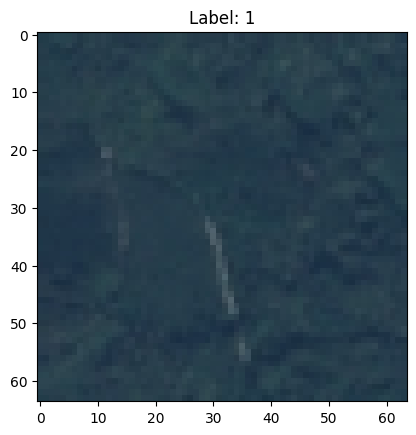

In [4]:
import matplotlib.pyplot as plt

# Cogemos una imagen del dataset
image, label = trainset[4]

# Cambiamos el formato de la imagen de (Canales, Alto, Ancho)
# a (Alto, Ancho, Canales) para poder mostrarla
image = image.permute(1, 2, 0)

plt.imshow(image)

plt.title(f"Label: {label}")

plt.show()

In [5]:
import torch

# Cogemos una imagen del dataset
X, label = trainset[7]

X = X.unsqueeze(0)

model.eval()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Movemos la imagen al mismo dispositivo que el modelo
X = X.to(device)

# Movemos el modelo al dispositivo
model = model.to(device)

with torch.no_grad():
    # Hacemos la predicción
    y_pred = model(X)

    # Nos quedamos con la clase con mayor probabilidad
    pred_class = torch.argmax(y_pred, dim=1)

print("Clase real:", label)

print("Predicción:", pred_class.item())

Clase real: 2
Predicción: 2


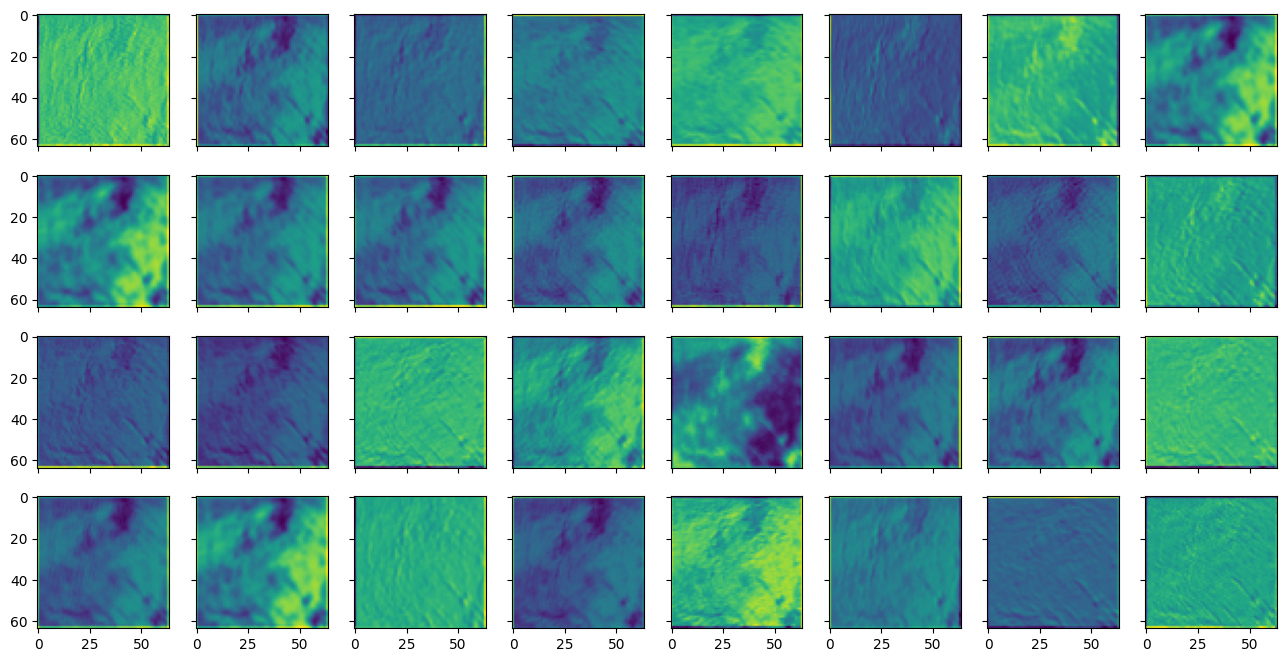

In [6]:
# Desactivamos el cálculo de gradientes
with torch.no_grad():
    # Pasamos la imagen por la primera capa convolucional del modelo
    feature_maps = model.conv1(X.to(device))

# Creamos una cuadrícula de 4 filas y 8 columnas para mostrar los mapas
fig, ax = plt.subplots(4, 8, sharex=True, sharey=True, figsize=(16, 8))

# Recorremos los 32 mapas de características
for i in range(0, 32):
    row, col = i // 8, i % 8

    ax[row][col].imshow(feature_maps[0][i].cpu().numpy())

# Mostramos la figura final
plt.show()

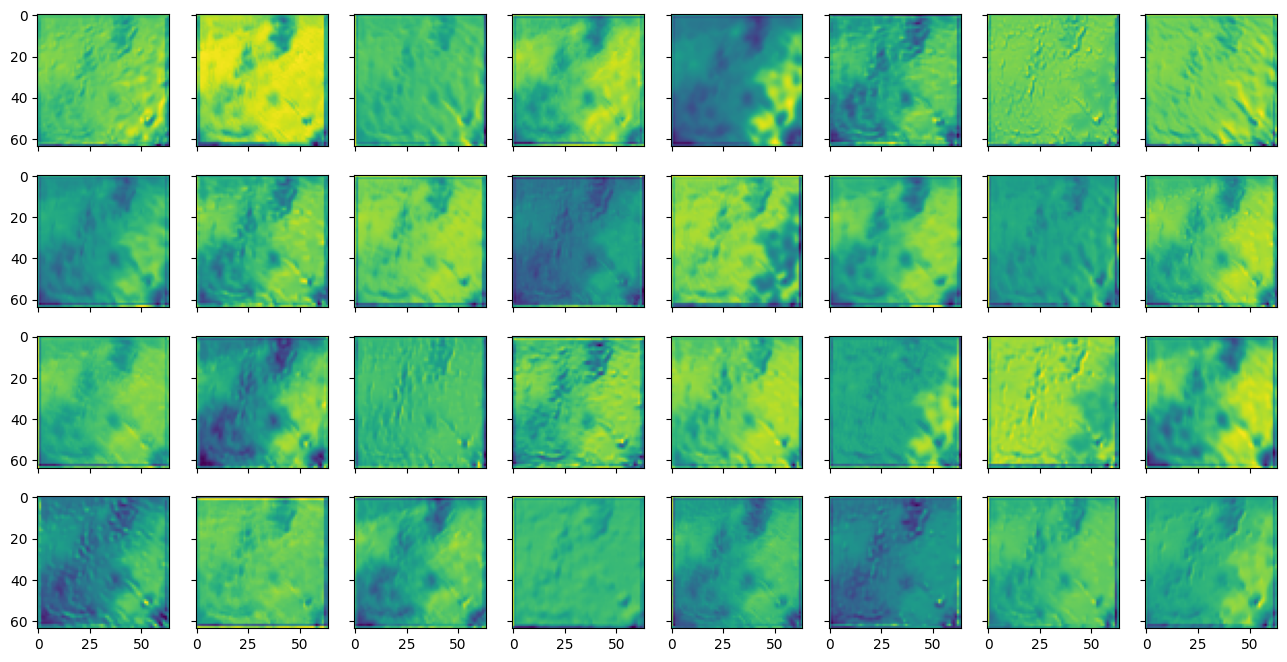

In [7]:
# Desactivamos gradientes porque solo queremos visualizar
with torch.no_grad():

    feature_maps = model.conv1(X.to(device))

    feature_maps = model.act1(feature_maps)

    # Apagamos algunas neuronas aleatoriamente)
    feature_maps = model.drop1(feature_maps)

    # Pasamos por la segunda capa convolucional
    feature_maps = model.conv2(feature_maps)

# Creamos una cuadrícula para mostrar los mapas de características
fig, ax = plt.subplots(4, 8, sharex=True, sharey=True, figsize=(16, 8))

for i in range(0, 32):
    row, col = i // 8, i % 8

    ax[row][col].imshow(feature_maps[0][i].cpu().numpy())

# Mostramos la figura
plt.show()